# Benchmarking dependency measures for marker-gene identification in multi-modal single-cell data

**PbenchmarkC CITE-seq (Hao et al. 2021) — a 2×2 decomposition of dependency measures.**
**Granularity: L2 (~30 cell types).**

|            | Marginal                | Conditional                       |
|------------|-------------------------|-----------------------------------|
| **Linear**    | Spearman correlation    | Partial correlation (shrinkage)   |
| **Nonlinear** | Mutual information (KSG) | Integrated Gradients on an MLP     |

We ask whether *nonlinearity* and *multivariate context* change which genes are
identified as cell-type markers, and which axis matters more. Every method sees
**RNA only**; the surface-protein (ADT) modality is used solely to define a
cross-modal, protein-derived ground-truth driver set $D_c$ per cell type. Recovery
of $D_c$ is scored with the parameter-free $\mathrm{AUC_{rel}}$ metric.

All heavy logic lives in the importable `src/` package.
This notebook only shows the good parts and presents the narrative.

See `README.md` for the full list of design decisions.


In [1]:
from IPython import display
from numpy.ma.extras import unique
%reload_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src import (
    config,
    data,
    ground_truth,
    mappings,
    # scorers,
    benchmark,
    stats,
    metric,
    plotting,
    preprocessing
)

from src.rna import preprocessing as rna_preprocessing
from src.adt import preprocessing as adt_preprocessing

In [2]:
config.set_log_level_critical()
plotting.set_style()
LEVEL = "celltype.l2"
PLOTTING_TAG = ""
rng = np.random.default_rng(config.SEED)

## 1. The Data

We use data from made available by Hao 2021 3 (CITE-seq data, GEO `GSE164378`: whole-transcriptome RNA + 228
surface proteins + donor / `celltype.l1/l2/l3` labels).

It was downloaded and subsampled to ~25k cells using **sqrt-proportional stratified subsampling** and saved as a MuData dataset (.h5mu – annotated multimodal data). This was done once, reducing the data size from ~1.4G to ~500M and locally saved.

## Load the data

In [144]:
# Load the multi modal dataset
dataset = data.create_or_load_dataset()
rna_dataset, adt_dataset = dataset["rna"], dataset["adt"]

print(f"Cell count: {rna_dataset.n_obs:,}")
print(f"RNA: {rna_dataset.n_vars:,} genes")
print(f"ADT: {adt_dataset.n_vars} proteins")

Cell count: 24,735
RNA: 33,538 genes
ADT: 228 proteins


### Level

In this notebook we are looking at `L2` labeling: cells are classified to `30` categories


In [427]:
rna_dataset.obs[LEVEL]

L1_AAACCCACACGTACTA                  NK
L1_AAACCCACATGGATCT      B intermediate
L1_AAACCCATCTTAAGGC             CD4 CTL
L1_AAACGAAAGATAACAC             B naive
L1_AAACGAACAATGAGCG             CD4 TCM
                              ...      
E2L8_TTTGGAGAGGAAGAAC                NK
E2L8_TTTGGTTAGGCCTGCT         CD4 Naive
E2L8_TTTGGTTTCAATCCAG         CD8 Naive
E2L8_TTTGTTGCAGCGTGAA         CD4 Naive
E2L8_TTTGTTGGTTGGCTAT         CD16 Mono
Name: celltype.l2, Length: 24735, dtype: category
Categories (30, object): ['ASDC', 'B intermediate', 'B memory', 'B naive', ..., 'cDC2', 'dnT', 'gdT', 'pDC']

#### The RNA Data

The matrix:
* rows = observations (cells) (~25k)
* cols = variables (genes) (~33k)

In [62]:
rna_dataset.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 53203323 stored elements and shape (24735, 33538)>

**Observation annotation data (rows)**

Annotation data for the observations/rows — metadata about cells.

In [63]:
rna_dataset.obs.head()

,nCount_ADT,nFeature_ADT,nCount_RNA,nFeature_RNA,orig.ident,lane,donor,time,celltype.l1,celltype.l2,celltype.l3,Phase,Batch
L1_AAACCCACACGTACTA,3567,202,4786,1890,SeuratProject,L1,P3,7,NK,NK,NK_2,G1,Batch1
L1_AAACCCACATGGATCT,8210,222,3589,1122,SeuratProject,L1,P4,2,B,B intermediate,B intermediate lambda,G1,Batch1
L1_AAACCCATCTTAAGGC,5382,215,4016,1451,SeuratProject,L1,P2,2,CD4 T,CD4 CTL,CD4 CTL,S,Batch1
L1_AAACGAAAGATAACAC,5155,216,3393,1092,SeuratProject,L1,P2,2,B,B naive,B naive kappa,S,Batch1
L1_AAACGAACAATGAGCG,5465,211,7379,2315,SeuratProject,L1,P1,7,CD4 T,CD4 TCM,CD4 TCM_2,G1,Batch1


**Variable annotation data (columns)**

Annotation data for the columns — the gene names.

In [64]:
rna_dataset.var.head()

,gene_name
rna:MIR1302-2HG,MIR1302-2HG
rna:FAM138A,FAM138A
rna:OR4F5,OR4F5
rna:AL627309.1,AL627309.1
rna:AL627309.3,AL627309.3


#### The Surface Proteins Data

The matrix:
* rows = observations (cells) (~25k)
* cols = variables (surface proteins) (228)

In [68]:
adt_dataset.X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 5114286 stored elements and shape (24735, 228)>

**Observation annotation data (rows)**

Annotation data for the observations/rows — metadata about cells.

In [66]:
adt_dataset.obs.head()

,nCount_ADT,nFeature_ADT,nCount_RNA,nFeature_RNA,orig.ident,lane,donor,time,celltype.l1,celltype.l2,celltype.l3,Phase,Batch
L1_AAACCCACACGTACTA,3567,202,4786,1890,SeuratProject,L1,P3,7,NK,NK,NK_2,G1,Batch1
L1_AAACCCACATGGATCT,8210,222,3589,1122,SeuratProject,L1,P4,2,B,B intermediate,B intermediate lambda,G1,Batch1
L1_AAACCCATCTTAAGGC,5382,215,4016,1451,SeuratProject,L1,P2,2,CD4 T,CD4 CTL,CD4 CTL,S,Batch1
L1_AAACGAAAGATAACAC,5155,216,3393,1092,SeuratProject,L1,P2,2,B,B naive,B naive kappa,S,Batch1
L1_AAACGAACAATGAGCG,5465,211,7379,2315,SeuratProject,L1,P1,7,CD4 T,CD4 TCM,CD4 TCM_2,G1,Batch1


**Variable annotation data (columns)**

Annotation data for the columns — the gene names.

In [67]:
adt_dataset.var.head()

,protein_name
adt:CD39,CD39
adt:Rat-IgG1-1,Rat-IgG1-1
adt:CD107a,CD107a
adt:CD62P,CD62P
adt:TCR-2,TCR-2


## 2. Normalization

Here we preprocess, normalize and transform the data.

* Quality control
* Normalization:
  * RNA - normalize counts, logarithmize
  * ADT - Centered-log-ratio (CLR)
* Feature selection:
  * HVG - highly variable selection
  * Ground truth markers - the genes that encode the known surface proteins

We select only the features (genes) that are either HVG or ground truth markers.

The four methods then work on the same, **identical**, matrix `X`
* rank-transformed
* z-scored expression
* The per-gene average-rank transform also collapses dropout zeros to a shared rank, mitigating the zero-inflation confound for MI.

### Quality Control

The data went through rigorous QC in the origin (Hau et al.). However, we have subsampled the cells in dataset preparation (see `src/data.py`),
which inevitebly sqewed the data in one way or another.

Here we validate and renormalize the subsampled data.

#### Before normalization

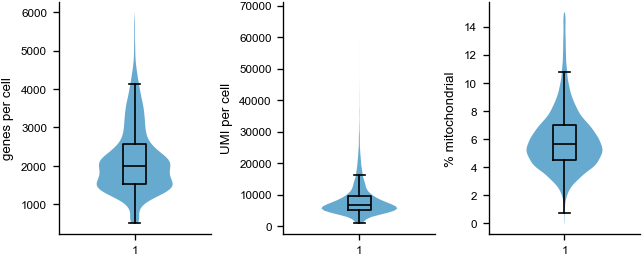

In [5]:
rna_preprocessing.calculate_qc_metrics_in_place(rna_dataset)
qc_metrics_df = rna_dataset.obs[["n_genes_by_counts",
                                 "total_counts",
                                 "pct_counts_mito"]]

qc_metrics_df = qc_metrics_df.rename(
    columns={"n_genes_by_counts": "genes per cell",
             "total_counts": "UMI per cell",
             "pct_counts_mito": "% mitochondrial"})

fig = plotting.qc_violins(qc_metrics_df, qc_metrics_df.columns)
# _ = plotting.save(fig, f"fig_qc_metrics_before_normalization{PLOTTING_TAG}")

In [157]:
rna_preprocessing.normalize_in_place(rna_dataset)
adt_preprocessing.normalize_in_place(adt_dataset)

#### After normalization

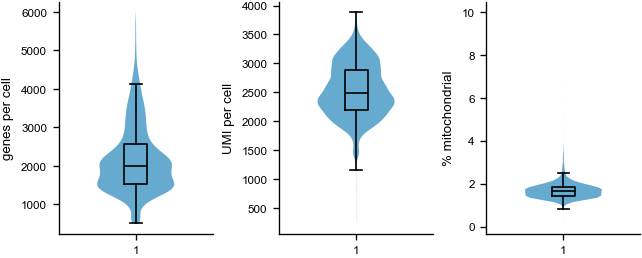

In [7]:
rna_preprocessing.calculate_qc_metrics_in_place(rna_dataset)
qc_metrics_df = rna_dataset.obs[["n_genes_by_counts",
                                 "total_counts",
                                 "pct_counts_mito"]]

qc_metrics_df = qc_metrics_df.rename(
    columns={"n_genes_by_counts": "genes per cell",
             "total_counts": "UMI per cell",
             "pct_counts_mito": "% mitochondrial"})

fig = plotting.qc_violins(qc_metrics_df, qc_metrics_df.columns)
# _ = plotting.save(fig, f"fig_qc_metrics_after_normalization{PLOTTING_TAG}")

### Feature selection

In [8]:
# RNA: Highly variable gened (HVGs)
rna_preprocessing.annotate_highly_variable_genes(rna_dataset)
hvgs = rna_preprocessing.get_highly_variable_genes(rna_dataset)

In [10]:
# Find the ground truth markers: the genes that encode the surface proteins
surface_protein_encoding_genes = mappings.all_candidate_genes(
    adt_dataset.var["protein_name"])
expressed_genes = rna_dataset.var["gene_name"]

surface_proteins = surface_protein_encoding_genes.intersection(
    expressed_genes)

# Compose the set of genes of interest: HVGs and ground truth markers
hv_genes = surface_proteins.union(hvgs)

# Subset the main RNA dataset
hv_gene_mask = rna_dataset.var["gene_name"].isin(sorted(hv_genes))
rna_dataset_hv = rna_dataset[:, hv_gene_mask]


In [11]:
matrix_of_interest = rna_preprocessing.build_matrix_of_interest(rna_dataset_hv)
print(
    f"HVGs {len(hvgs)} | Surface proteins {len(surface_proteins)} | Genes of interest {len(hv_genes)}")
print("Matrix of interest:", matrix_of_interest.shape, matrix_of_interest.dtype)

HVGs 2000 | Surface proteins 133 | Genes of interest 2133
Matrix of interest: (24735, 133) float32


### Scaling

After normalization and filtering by HVGs, we can scale the data to mean=0 and sd=1.

In [12]:
rna_preprocessing.scale_in_place(rna_dataset_hv)

/opt/homebrew/Caskroom/miniconda/base/envs/data_science_in_life_sciences_project_2026_group_1/lib/python3.11/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/opt/homebrew/Caskroom/miniconda/base/envs/data_science_in_life_sciences_project_2026_group_1/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


## 3. Exploration: UMAP, donor batch effect

PCA → UMAP on the HVGs, with **Harmony** batch correction over the 8 donors. The
donor UMAPs (before/after) show whether batch correction is warranted.

In [13]:
cell_types = rna_dataset.obs[LEVEL]
donors = rna_dataset.obs[config.DONOR_KEY]

### PCA Embedding (dimentionality reduction)

In [14]:
rna_preprocessing.perform_pca_in_place(rna_dataset)
rna_preprocessing.perform_pca_harmony_in_place(rna_dataset)

2026-06-22 23:43:28,309 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-06-22 23:43:28 [INFO] Computing initial centroids with sklearn.KMeans...
2026-06-22 23:43:30,305 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-06-22 23:43:30 [INFO] sklearn.KMeans initialization complete.
2026-06-22 23:43:30,393 - harmonypy - INFO - Iteration 1 of 10
2026-06-22 23:43:30 [INFO] Iteration 1 of 10
2026-06-22 23:43:34,607 - harmonypy - INFO - Iteration 2 of 10
2026-06-22 23:43:34 [INFO] Iteration 2 of 10
2026-06-22 23:43:39,549 - harmonypy - INFO - Iteration 3 of 10
2026-06-22 23:43:39 [INFO] Iteration 3 of 10
2026-06-22 23:43:43,930 - harmonypy - INFO - Iteration 4 of 10
2026-06-22 23:43:43 [INFO] Iteration 4 of 10
2026-06-22 23:43:46,528 - harmonypy - INFO - Iteration 5 of 10
2026-06-22 23:43:46 [INFO] Iteration 5 of 10
2026-06-22 23:43:48,003 - harmonypy - INFO - Converged after 5 iterations
2026-06-22 23:43:48 [INFO] Converged after 5 iterations


/opt/homebrew/Caskroom/miniconda/base/envs/data_science_in_life_sciences_project_2026_group_1/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


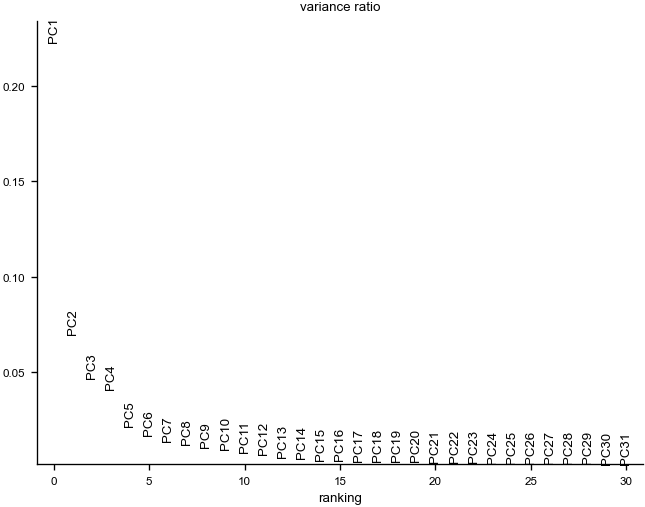

In [158]:
plotting.pca_variance_ratio(rna_dataset)

#### PCA Plots

We see the applied batch effect correction (harmony, top right)

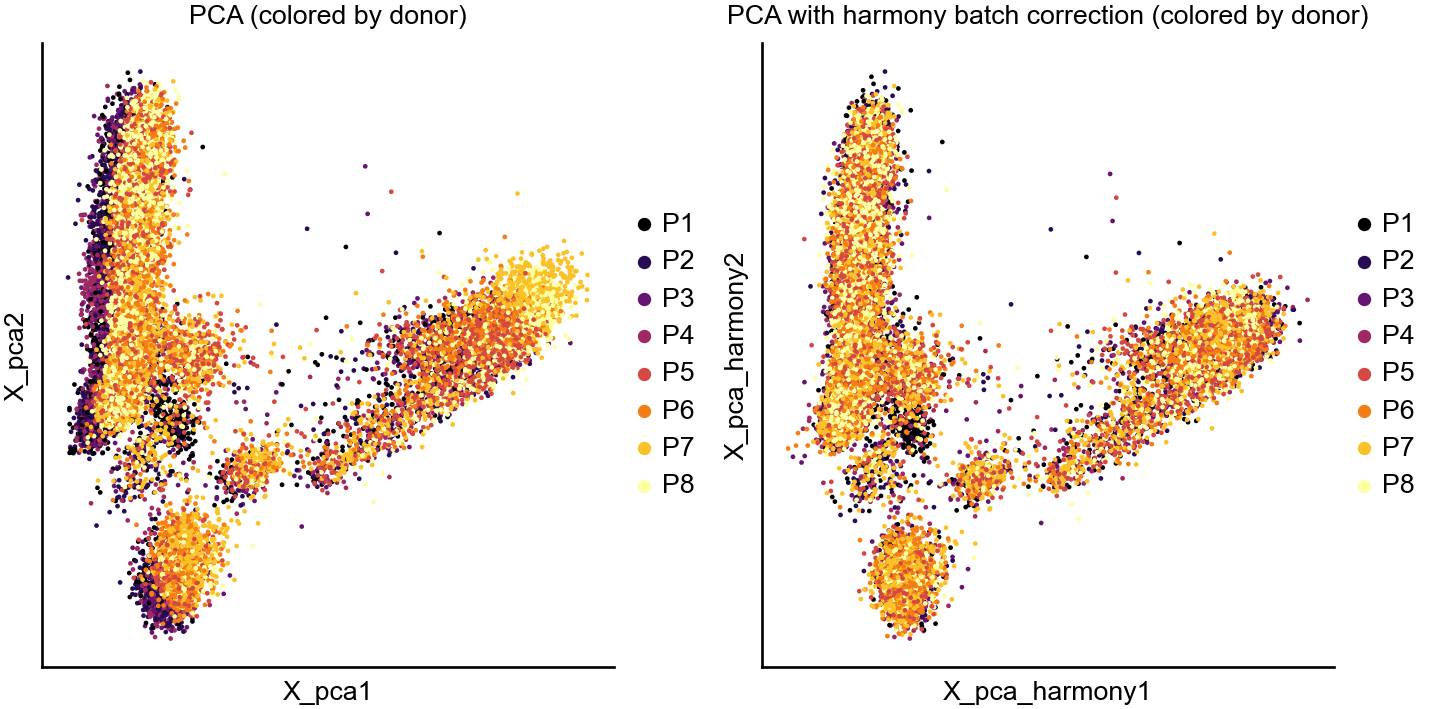

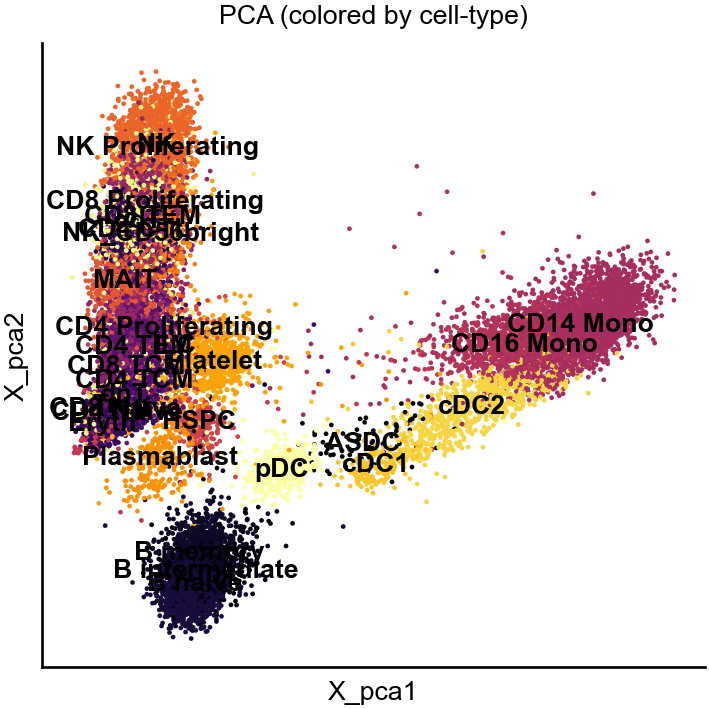

In [173]:
_, axes = plt.subplots(ncols=2, figsize=(6, 3))

plotting.plot_embedding(rna_dataset,
                        obsm_key="X_pca",
                        title="PCA (colored by donor)",
                        color_by_key="donor",
                        ax=axes[0])
plotting.plot_embedding(rna_dataset,
                        obsm_key="X_pca_harmony",
                        title="PCA with harmony batch correction (colored by donor)",
                        color_by_key="donor",
                        ax=axes[1])

plotting.plot_embedding(rna_dataset,
                        obsm_key="X_pca",
                        title="PCA (colored by cell-type)",
                        color_by_key=LEVEL,
                        legend_loc="on data")

#### UMAP embedding (dimentionality reduction)

In [34]:
rna_preprocessing.perform_umap_in_place(rna_dataset)
rna_preprocessing.perform_umap_harmony_in_place(rna_dataset)

/opt/homebrew/Caskroom/miniconda/base/envs/data_science_in_life_sciences_project_2026_group_1/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**UMAP Plots**

We see the applied batch effect correction (harmony, top right)


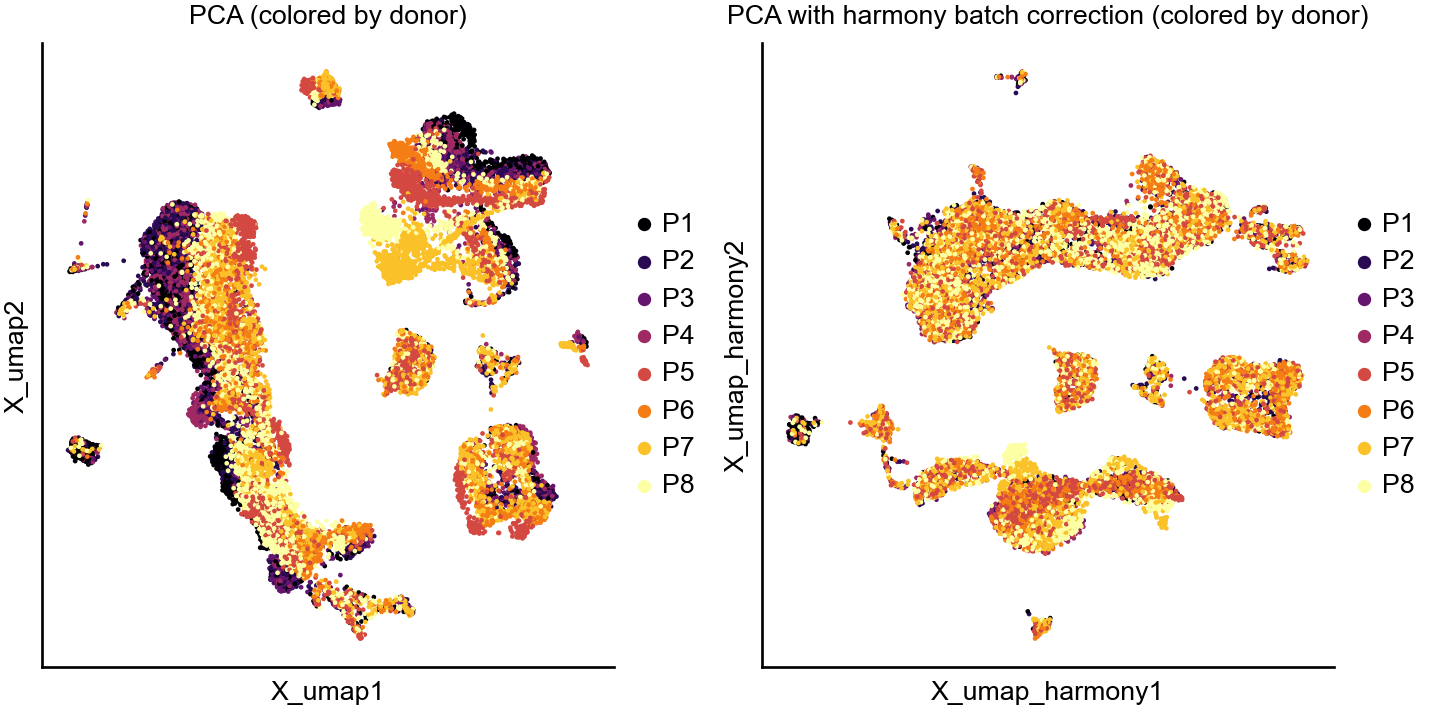

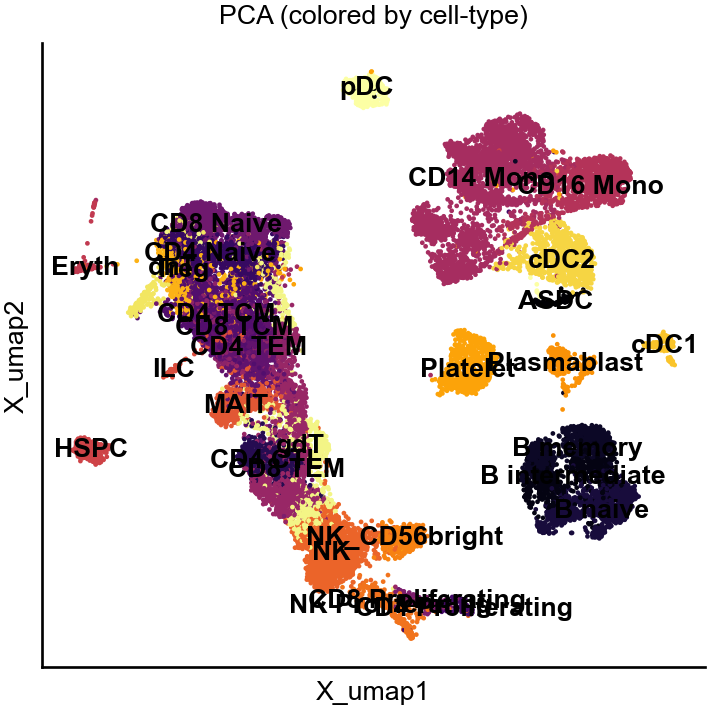

In [174]:
_, axes = plt.subplots(ncols=2, figsize=(6, 3))
plotting.plot_embedding(rna_dataset,
                        obsm_key="X_umap",
                        title="PCA (colored by donor)",
                        color_by_key="donor",
                        ax=axes[0])
plotting.plot_embedding(rna_dataset,
                        obsm_key="X_umap_harmony",
                        title="PCA with harmony batch correction (colored by donor)",
                        color_by_key="donor",
                        ax=axes[1])

plotting.plot_embedding(rna_dataset,
                        obsm_key="X_umap",
                        title="PCA (colored by cell-type)",
                        color_by_key=LEVEL,
                        legend_loc="on data")

## Sanity check: cell-type label validation

Here we compare the cell type labeling from two directions:
1. The ground truth — marker proteins labeling provided by the original paper (Hao et al.)
2. "Molecular evidence" - cell-type labeling based on the observed surface protein

We take the list of all marker proteins for all cell types in the dataset (14 in total) as our ground truth: cell type -> marker protein

From the data we then compute the average levels per surface protein over each cell-type: marker potein -> cell type



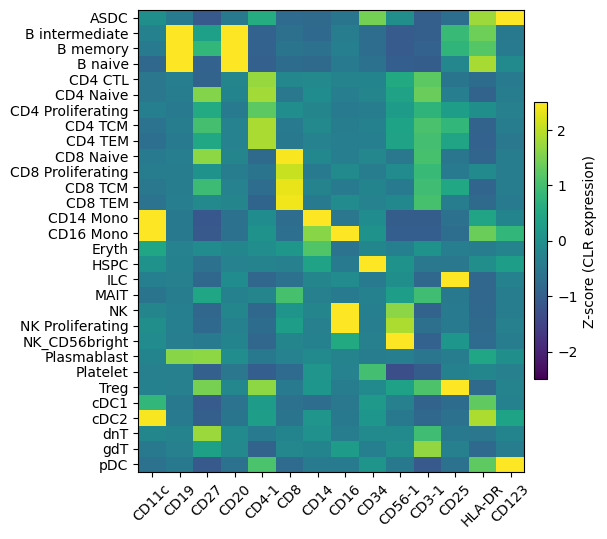

In [170]:
cell_protein_markers_ground_truth = set(
    mappings.CELL_TYPE_TO_MARKER_PROTEIN.values())
proteins_in_dataset = set(adt_dataset.var["protein_name"])

cell_marker_proteins_in_dataset = list(
    cell_protein_markers_ground_truth.intersection(
        proteins_in_dataset))

df = pd.DataFrame(
    adt_dataset.layers["clr"].toarray(),
    index=adt_dataset.obs_names,
    columns=adt_dataset.var["protein_name"]
)

# Ground truth
df["cell_type"] = adt_dataset.obs[LEVEL]

# Mean expression level for each protein groupped by cell-type
df = df.groupby("cell_type", observed=False).mean()

# Normalize protein levels (Z-score)
df_z_score = (df - df.mean()) / df.std()
df_z_score["marker_protein"] = df_z_score.index.map(mappings.CELL_TYPE_TO_MARKER_PROTEIN)

# Order the columns to match the cell type order
# The fist protein (X axis) should correspond to the first cell type (Y axis, from the top)
# This should produce a decsending diagonal.
markers_in_order = df_z_score["marker_protein"].unique()
df = df_z_score[markers_in_order]

# Plot
plotting.protein_marker_validation_heatmap(df)

## 4. Protein-derived ground truth $D_c$

For each cell type we take the top surface proteins by one-vs-rest Wilcoxon score on CLR-ADT (p-values are uninformative at n≈25k), mapped to encoding gene(s) by molecular fact only (`src.protein_gene_map`) intersected with the scored gene universe. This is independent of all four RNA methods.

In [527]:
from src import ground_truth

drivers, details = ground_truth.build_ground_truth(adt_dataset,
                                                   LEVEL,
                                                   genes_of_interest=hv_genes)
# summary = ground_truth.summarise_drivers(drivers)
# summary.to_csv(config.tab_path(f"ground_truth_summary{PLOTTING_TAG}"),
#                index=False)
# summary

/opt/homebrew/Caskroom/miniconda/base/envs/data_science_in_life_sciences_project_2026_group_1/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/opt/homebrew/Caskroom/miniconda/base/envs/data_science_in_life_sciences_project_2026_group_1/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/opt/homebrew/Caskroom/miniconda/base/envs/data_science_in_life_sciences_project_2026_group_1/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/opt/homebrew/Caskroom/miniconda/base/envs/data_science_in_life_sciences_project_2026_group_1/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encoun

In [533]:
import scanpy as sc

adt_dataset.obs[LEVEL].tolist()
df = sc.get.rank_genes_groups_df(adt_dataset, group="B intermediate")
df = df[(df["pvals_adj"] < 0.05)
        & (df["logfoldchanges"] > 0.0)
        & (df["scores"] > 0)]
df = df.sort_values("scores", ascending=False)
df = df.head(10)
df

,names,scores,logfoldchanges,pvals,pvals_adj
0,adt:CD19,42.238415,5.056276,0.000000e+00,0.000000e+00
2,adt:CD72,41.810535,6.374158,0.000000e+00,0.000000e+00
3,adt:CD196,40.894772,3.036392,0.000000e+00,0.000000e+00
5,adt:CD22,40.833618,5.339919,0.000000e+00,0.000000e+00
9,adt:CD79b,36.048420,3.562078,1.459978e-284,3.328750e-283
11,adt:CD39,34.651199,4.598296,4.285108e-263,8.141706e-262
13,adt:CD45RA,33.904778,2.858799,5.664815e-252,8.610519e-251
15,adt:CD52,31.801844,1.129367,6.104187e-222,8.186792e-221
16,adt:HLA-DR,30.980295,2.726899,9.933805e-211,1.192057e-209
17,adt:CD275-2,29.756966,3.610781,1.409178e-194,1.529965e-193


## 5. The four dependency measures

All operate on the shared matrix `X` and a binary one-vs-rest indicator.

### 5.1 Linear · marginal — Spearman correlation
### 5.2 Linear · conditional — partial correlation (shrinkage)
The empirical gene covariance is ill-conditioned (dropout, collinearity, $p\apreprocessingrox n$),
so a naïve precision matrix is unstable. We use a **Ledoit–Wolf shrinkage**
covariance → precision → point-biserial partial correlation. The eigen-spectrum
below motivates the shrinkage.

In [ ]:
from sklearn.covariance import LedoitWolf

Xs = matrix_of_interest - matrix_of_interest.mean(0, keepdims=True)
emp = np.linalg.eigvalsh(np.cov(Xs.T))
lw = np.linalg.eigvalsh(LedoitWolf(assume_centered=True).fit(Xs).covariance_)
fig, _ = plotting.eigen_spectrum(emp, lw);
plotting.save(fig, f"fig_pcorr_eigenspectrum{PLOTTING_TAG}");
fig

### 5.3 Nonlinear · marginal — KSG mutual information
Kraskov–Stögbauer–Grassberger kNN estimator on the rank-transformed expression,
computed one-vs-rest per cell type (parallelised across cell types, estimated on a
fixed 10k-cell subsample for tractability).

In [ ]:
valid = [ct for ct, d in drivers.items()
         if len([g for g in d if g in set(genes)]) >= config.MIN_DRIVERS]
mi_attr = benchmark.compute_mi_parallel(matrix_of_interest,
                                        rna_dataset.obs[LEVEL].astype(
                                            str).values,
                                        valid,
                                        n_jobs=-1, seed=config.SEED)
_ex = valid[0]
fig, _ = plotting.score_hist(mi_attr[_ex], f"mutual information — {_ex}");
plotting.save(fig, f"fig_mi_hist{PLOTTING_TAG}");
fig

### 5.4 Nonlinear · conditional — Integrated Gradients on an MLP
A small classifier with `tanh` hidden layers and a `softmax` output (predictions
on the simplex), trained with cross-entropy + inverse-frequency class weights and
early stopreprocessinging on validation loss. Integrated Gradients then attributes each class
to the input genes.

**Architecture selection (CV macro-F1 sweep).** Overall accuracy hides
minority-class behaviour, so we select the `tanh`-MLP architecture by 3-fold
cross-validated **macro-F1** (every cell type weighted equally), which targets the
harder, less-abundant lineages. The winning configuration — hidden (512, 256),
dropout 0.4, lr 3e-4, weight decay 1e-4 — is the default in `src.mlp.train_mlp`.

In [ ]:
from src import mlp as mlpmod

y = rna_dataset.obs[LEVEL].astype(str).values
default_cfg = dict(hidden=(256, 128), dropout=0.2, lr=1e-3, weight_decay=1e-5)
tuned_cfg = dict(hidden=(512, 256), dropout=0.4, lr=3e-4, weight_decay=1e-4)

At this granularity (30 classes) the sweep is expensive, so it is run
via `run_pipeline.py tune` and its results / per-class diagnostics are loaded here.

In [ ]:
from IPython.display import Image

sw = config.tab_path(f"mlp_hyperparam_search{PLOTTING_TAG}")
display(pd.read_csv(sw)) if os.path.exists(sw) else None

In [ ]:
# per-class F1 (default vs tuned) and confusion matrix from the CV sweep
for _n in ("fig_mlp_per_class_f1", "fig_mlp_confusion"):
    _f = plotting.get_or_create_figure_dir("png") / f"{_n}.png"
if _f.exists(): display(Image(str(_f)))

The final classifier is trained on all cells with the tuned architecture
(the `src.mlp` default), then Integrated Gradients is computed.

In [ ]:
trained = mlpmod.train_mlp(matrix_of_interest, y, seed=config.SEED)
print(
    f"held-out test accuracy: {trained.test_acc:.3f}  (best epoch {trained.history.best_epoch})")
fig, _ = plotting.mlp_training_curves(trained.history);
plotting.save(fig, f"fig_mlp_training{PLOTTING_TAG}");
fig

In [ ]:
attr = mlpmod.integrated_gradients(trained, matrix_of_interest, y,
                                   seed=config.SEED)
classes = list(trained.classes)
ig_attr = {ct: attr[:, classes.index(ct)] for ct in classes}
print("IG attributions:", attr.shape, "(genes × classes)")

UMAP of the MLP's penultimate-layer representation — the nonlinear,
class-discriminative geometry the attributions are read from.

In [ ]:
import umap

memb = mlpmod.mlp_embedding(trained, matrix_of_interest)
mu = umap.UMAP(random_state=config.SEED).fit_transform(memb)
fig, _ = plotting.embedding_scatter(mu, cell_types);
plotting.save(fig, f"fig_mlp_umap{PLOTTING_TAG}");
fig

## 6. Benchmark: driver recovery ($\mathrm{AUC_{rel}}$)

$\mathrm{AUC_{rel}}$ is the normalized driver-recovery AUC (≡ Mann–Whitney ROC-AUC
of the per-gene score discriminating drivers from non-drivers): 0.5 = random,
1.0 = perfect, parameter-free, defined on every method's output.

In [ ]:
store = {}
res = benchmark.run_benchmark(matrix_of_interest, genes, y, drivers,
                              mi_attr=mi_attr,
                              ig_attr=ig_attr,
                              store_scores=store, seed=config.SEED)
res.to_csv(config.tab_path(f"benchmark_auc_rel{PLOTTING_TAG}"), index=False)
res.pivot_table(index="celltype", columns="method", values="auc_rel").round(3)

Cumulative recovery curve **averaged over cell types** (bootstrap-over
-cell-type band; x = fraction of all ranked genes). Its area is exactly
$\mathrm{AUC_{rel}}$.

In [ ]:
panel = {ct: {m: metric.recovery_curve(store[ct][m], store[ct]["_driver_mask"])
              for m in config.METHODS} for ct in sorted(store)}
fig, _ = plotting.recovery_curve_mean(store, config.METHODS);
plotting.save(fig, f"fig_recovery_curves{PLOTTING_TAG}");
fig

## 7. Statistical comparison

The unit of replication is the **cell type** (paired across methods): a Friedman
omnibus test, then Holm-corrected pairwise Wilcoxon signed-rank tests with
matched-pairs rank-biserial effect sizes.

In [ ]:
wide = stats.pivot_auc(res)
fried = stats.friedman_test(wide)
print(f"Friedman χ² = {fried['statistic']:.2f}, p = {fried['pvalue']:.2e} "
      f"(n = {fried['n_celltypes']} cell types)")
pw = stats.pairwise_wilcoxon(wide, method_order=config.METHODS)
pw.to_csv(config.tab_path(f"pairwise_wilcoxon{PLOTTING_TAG}"), index=False)
pw

In [ ]:
sig = [(r.method_a, r.method_b, "*" if r["significant_0.05"] else "ns")
       for _, r in pw.iterrows()]
fig, _ = plotting.auc_box(res, config.METHODS, sig_pairs=sig);
plotting.save(fig, f"fig_auc_box{PLOTTING_TAG}");
fig

In [ ]:
fig, _ = plotting.auc_heatmap(wide, method_order=config.METHODS);
plotting.save(fig, f"fig_auc_heatmap{PLOTTING_TAG}");
fig

### 7.1 Early recovery (recall@k) and sensitivity to heterogeneous categories

$\mathrm{AUC_{rel}}$ integrates the *entire* ranking, but a practitioner only
inspects the top handful of genes. **Recall@k** (fraction of drivers within the
top-k) targets that early regime; the band is a bootstrap over cell types (the
replication unit). Note the axes differ from the per-cell-type curves above: here
x is the **absolute** top-k (a few dozen genes) **averaged over all cell types**,
whereas those curves use the *fraction* of all genes for a *single* type — so a
single-type curve reaching 100% early and a middling cross-type average are
consistent, not contradictory. The whole-curve winner and the early-recovery
winner need not agree.

**Recall@k averaged over cell types** (bootstrap-over-cell-type band);
x is the absolute top-k. The whole-curve winner and the early-recovery winner need
not agree, though here the marginal methods lead throughout.

In [ ]:
rk = benchmark.recovery_at_k_table(store, methods=config.METHODS)
rk.to_csv(config.tab_path(f"recovery_at_k{PLOTTING_TAG}"), index=False)
fig, _ = plotting.recovery_at_k_curve(rk, config.METHODS);
plotting.save(fig, f"fig_recovery_at_k{PLOTTING_TAG}");
fig

Heterogeneous grab-bag categories (e.g. `other`, `other T`) have weak,
ambiguous protein-derived ground truth and depress recovery for *all* methods —
Integrated Gradients most. The table below (mean AUC_rel with vs without them) is a
transparency check showing how much the aggregate understates the model-based
method on cleanly-defined cell types.

In [ ]:
hetero = [c for c in res.celltype.unique() if "other" in c.lower()]
print("heterogeneous categories at this granularity:", hetero or "none")
sens = pd.DataFrame({"mean_auc_all": res.groupby("method").auc_rel.mean()})
if hetero:
    sens["mean_auc_excl_other"] = res[~res.celltype.isin(hetero)].groupby(
        "method").auc_rel.mean()
sens.round(3).loc[config.METHODS]

## 8. Cross-method comparison (gene level)

Pooling every (gene, cell type) score (z-scored within cell type), how do the four
measures relate, and where do the protein-confirmed drivers sit? The pairwise
scatter matrix and the 3-D view (partial correlation × MI × IG) make the
agreement/disagreement structure explicit; protein-derived drivers are
highlighted.

In [ ]:
long = benchmark.scores_to_long(store, genes)
long.to_parquet(
    config.PROCESSED_DATA_DIR_PATH / f"scores_long{PLOTTING_TAG}.parquet")
fig, _ = plotting.pairwise_scatter_matrix(long, config.METHODS);
plotting.save(fig, f"fig_pairwise_scatter{PLOTTING_TAG}");
fig

In [ ]:
fig, _ = plotting.scatter3d(long, "partial_corr", "mi_ksg", "ig_mlp");
plotting.save(fig, f"fig_scatter3d{PLOTTING_TAG}", tight=False);
fig

## 9. Stability and robustness

Descriptive stability bands (not inference): **bootstrap over cells** for the
methods, and **MLP-seed variation** for Integrated Gradients. At this granularity
the bootstrap recomputes MI / refits many shrinkage covariances, so it is produced
by `run_pipeline.py stability` / `seed` (CLI) and loaded here.

In [ ]:
sb, ss = config.tab_path(f"stability_bootstrap{PLOTTING_TAG}"), config.tab_path(
    f"stability_seed{PLOTTING_TAG}")
if os.path.exists(sb): display(pd.read_csv(sb, index_col=0).round(3))
if os.path.exists(ss): display(pd.read_csv(ss).round(3))

## 10. Summary

The figures and tables above decompose marker-gene identification along the
linear/nonlinear and marginal/conditional axes against an independent,
protein-derived ground truth, at this annotation granularity. Comparing against
the other granularity's notebook indicates whether the conclusion (which
statistical assumption changes the recovered markers) is robust to how finely cell
types are defined. See the report for interpretation.
